# Optimisation et Modèles Avancés - Étape 3, Step 2

## Objectif
Utiliser les métriques de Machine Learning et de statistiques pour exploiter et comprendre au mieux les résultats, optimiser les modèles et tester des modèles plus complexes.

## Plan
1. Chargement des données et du meilleur modèle baseline
2. Analyse approfondie des métriques et résultats
3. Optimisation des hyperparamètres (GridSearch/RandomSearch)
4. Gestion du déséquilibre de classes (class weights, SMOTE)
5. Modèles avancés (XGBoost, LightGBM, CatBoost)
6. Comparaison complète de tous les modèles
7. Sélection du meilleur modèle final



In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
import pickle
warnings.filterwarnings('ignore')

# Ajouter le dossier src au path
sys.path.append(str(Path('../').resolve()))

# Import des modules
from src.utils.data_loader import load_data
from src.modeling import TFIDFVectorizer, BaselineModels, AdvancedModels
from src.optimization import (
    optimize_model,
    grid_search_optimization,
    random_search_optimization,
    create_class_weights,
    apply_smote,
    apply_adasyn
)
from src.evaluation import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix,
    plot_class_distribution
)

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Bibliothèques importées avec succès")



⚠️  XGBoost n'est pas installé. Installez-le avec: pip install xgboost
⚠️  LightGBM n'est pas installé. Installez-le avec: pip install lightgbm
⚠️  CatBoost n'est pas installé. Installez-le avec: pip install catboost
✅ Bibliothèques importées avec succès


## 1. Chargement des Données et du Modèle Baseline

Chargement des données préprocessées et du meilleur modèle baseline de Step 1.


In [2]:
# Chemins
DATA_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')

# Chargement des données
print("🔄 Chargement des données...")
X_train = pd.read_csv(DATA_DIR / 'X_train_clean.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test_clean.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv')

# Chargement du vectoriseur et du label encoder
print("🔄 Chargement du vectoriseur et du label encoder...")
vectorizer = TFIDFVectorizer.load(MODELS_DIR / 'tfidf_vectorizer.pkl')
with open(MODELS_DIR / 'label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Vectorisation
X_train_texts = X_train['text_combined'].astype(str)
X_test_texts = X_test['text_combined'].astype(str)
X_train_vect = vectorizer.transform(X_train_texts)
X_test_vect = vectorizer.transform(X_test_texts)

# Encodage des labels
y_train_labels = y_train['prdtypecode'].values
y_train_encoded = label_encoder.transform(y_train_labels)

# Division train/validation (même split que Step 1)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_vect,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

print(f"✅ Données chargées et préparées !")
print(f"  - Train : {X_train_split.shape[0]:,} échantillons")
print(f"  - Validation : {X_val_split.shape[0]:,} échantillons")
print(f"  - Test : {X_test_vect.shape[0]:,} échantillons")
print(f"  - Vocabulaire : {vectorizer.get_vocabulary_size():,} mots")



🔄 Chargement des données...
🔄 Chargement du vectoriseur et du label encoder...
✅ Données chargées et préparées !
  - Train : 67,932 échantillons
  - Validation : 16,984 échantillons
  - Test : 13,812 échantillons
  - Vocabulaire : 10,000 mots


## 2. Analyse Approfondie des Métriques Baseline

Analyse détaillée des performances du modèle baseline pour identifier les axes d'amélioration.


In [3]:
# Chargement du meilleur modèle baseline (SVM Linear)
print("🔄 Chargement du modèle baseline...")
# Chercher le fichier du modèle baseline
baseline_files = list(MODELS_DIR.glob('*baseline.pkl'))
if baseline_files:
    baseline_model = BaselineModels.load_model(baseline_files[0])
    print(f"✅ Modèle baseline chargé : {baseline_files[0].name}")
else:
    # Si pas de modèle sauvegardé, réentraîner rapidement
    print("⚠️  Modèle baseline non trouvé, réentraînement rapide...")
    baseline_model = LinearSVC(random_state=42, dual=False, max_iter=2000)
    baseline_model.fit(X_train_split, y_train_split)
    print("✅ Modèle baseline réentraîné")

# Prédictions baseline
y_pred_baseline = baseline_model.predict(X_val_split)

# Évaluation baseline
metrics_baseline = evaluate_model(y_val_split, y_pred_baseline)

print("="*80)
print("PERFORMANCES BASELINE (SVM Linear)")
print("="*80)
print(f"  - Accuracy : {metrics_baseline['accuracy']:.4f}")
print(f"  - F1-score (macro) : {metrics_baseline['f1_macro']:.4f}")
print(f"  - F1-score (weighted) : {metrics_baseline['f1_weighted']:.4f}")
print(f"  - Precision (macro) : {metrics_baseline['precision_macro']:.4f}")
print(f"  - Recall (macro) : {metrics_baseline['recall_macro']:.4f}")

# Analyse par classe
from sklearn.metrics import classification_report
report = classification_report(y_val_split, y_pred_baseline, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()

print(f"\n📊 Performances par classe (top 5 meilleures et pires) :")
print("\nTop 5 meilleures classes :")
print(df_report.nlargest(6, 'f1-score').head(5)[['precision', 'recall', 'f1-score', 'support']])

print("\nTop 5 pires classes :")
print(df_report.nsmallest(6, 'f1-score').tail(5)[['precision', 'recall', 'f1-score', 'support']])



🔄 Chargement du modèle baseline...
✅ Modèle baseline chargé : svm_(linear)_baseline.pkl
PERFORMANCES BASELINE (SVM Linear)
  - Accuracy : 0.8016
  - F1-score (macro) : 0.7843
  - F1-score (weighted) : 0.8008
  - Precision (macro) : 0.7942
  - Recall (macro) : 0.7783

📊 Performances par classe (top 5 meilleures et pires) :

Top 5 meilleures classes :
    precision    recall  f1-score  support
26   0.982759  0.982759  0.982759    174.0
23   0.959135  0.976983  0.967977   2042.0
10   0.943750  0.937888  0.940810    161.0
21   0.910714  0.919840  0.915254    998.0
9    0.880527  0.927651  0.903475   1009.0

Top 5 pires classes :
    precision    recall  f1-score  support
6    0.663551  0.464052  0.546154    153.0
8    0.635220  0.487923  0.551913    414.0
1    0.727924  0.607570  0.662324    502.0
7    0.725753  0.668378  0.695885    974.0
25   0.703499  0.692029  0.697717    552.0


## 3. Optimisation des Hyperparamètres

Optimisation des hyperparamètres du meilleur modèle baseline (SVM Linear) avec GridSearch et RandomSearch.


In [4]:
# Optimisation de SVM Linear avec RandomSearch (plus rapide que GridSearch)
print("="*80)
print("OPTIMISATION SVM LINEAR")
print("="*80)

# Grille de paramètres pour RandomSearch
svm_param_dist = {
    'C': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'penalty': ['l2'],
    'loss': ['squared_hinge'],
    'max_iter': [1000, 2000, 3000],
    'dual': [False]  # Pour datasets larges
}

# Création du modèle
svm_model = LinearSVC(random_state=42, dual=False)

# Optimisation
svm_optimized = random_search_optimization(
    svm_model,
    X_train_split,
    y_train_split,
    svm_param_dist,
    n_iter=20,  # Nombre de combinaisons à tester
    cv=3,  # 3 folds pour accélérer
    n_jobs=-1,
    random_state=42
)

# Évaluation du modèle optimisé
y_pred_svm_opt = svm_optimized['best_model'].predict(X_val_split)
metrics_svm_opt = evaluate_model(y_val_split, y_pred_svm_opt)

print(f"\n📊 Comparaison SVM Baseline vs Optimisé :")
print(f"  Baseline - F1-macro : {metrics_baseline['f1_macro']:.4f}")
print(f"  Optimisé  - F1-macro : {metrics_svm_opt['f1_macro']:.4f}")
print(f"  Amélioration : {(metrics_svm_opt['f1_macro'] - metrics_baseline['f1_macro']) / metrics_baseline['f1_macro'] * 100:+.2f}%")



OPTIMISATION SVM LINEAR
🔄 Optimisation des hyperparamètres (random)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Optimisation terminée !
   Meilleur score (CV) : 0.7684
   Meilleurs paramètres : {'penalty': 'l2', 'max_iter': 1000, 'loss': 'squared_hinge', 'dual': False, 'C': 0.5}

📊 Comparaison SVM Baseline vs Optimisé :
  Baseline - F1-macro : 0.7843
  Optimisé  - F1-macro : 0.7829
  Amélioration : -0.18%


## 4. Gestion du Déséquilibre de Classes

Application de techniques de rééquilibrage : class weights et SMOTE.


In [5]:
# Création des class weights
print("="*80)
print("CRÉATION DES CLASS WEIGHTS")
print("="*80)

class_weights = create_class_weights(y_train_split, method='balanced')

# Test avec SVM + class weights
print(f"\n🔄 Test SVM avec class weights...")
svm_weighted = LinearSVC(
    C=1.0,
    class_weight=class_weights,
    random_state=42,
    dual=False,
    max_iter=2000
)
svm_weighted.fit(X_train_split, y_train_split)
y_pred_svm_weighted = svm_weighted.predict(X_val_split)
metrics_svm_weighted = evaluate_model(y_val_split, y_pred_svm_weighted)

print(f"\n📊 Comparaison :")
print(f"  Baseline (sans weights) - F1-macro : {metrics_baseline['f1_macro']:.4f}")
print(f"  Avec class weights      - F1-macro : {metrics_svm_weighted['f1_macro']:.4f}")
print(f"  Amélioration : {(metrics_svm_weighted['f1_macro'] - metrics_baseline['f1_macro']) / metrics_baseline['f1_macro'] * 100:+.2f}%")



CRÉATION DES CLASS WEIGHTS
✅ Poids de classes calculés (balanced)
   Nombre de classes : 27
   Poids min : 0.3081
   Poids max : 4.1178
   Ratio max/min : 13.37

🔄 Test SVM avec class weights...

📊 Comparaison :
  Baseline (sans weights) - F1-macro : 0.7843
  Avec class weights      - F1-macro : 0.7776
  Amélioration : -0.85%


In [6]:
# Test avec SMOTE (optionnel - peut être long)
print("="*80)
print("TEST AVEC SMOTE")
print("="*80)
print("⚠️  Note : SMOTE peut être long sur de gros datasets. On utilise un échantillon pour tester.")

# Utiliser un échantillon pour tester SMOTE (optionnel)
USE_SMOTE = False  # Mettre à True pour tester SMOTE (peut être long)

if USE_SMOTE:
    # Échantillonner pour accélérer (optionnel)
    sample_size = min(10000, len(X_train_split))
    indices = np.random.choice(len(X_train_split), sample_size, replace=False)
    X_train_sample = X_train_split[indices]
    y_train_sample = y_train_split[indices]
    
    # Application de SMOTE
    X_train_smote, y_train_smote = apply_smote(
        X_train_sample,
        y_train_sample,
        sampling_strategy='auto',
        random_state=42
    )
    
    # Test avec SVM sur données SMOTE
    svm_smote = LinearSVC(C=1.0, random_state=42, dual=False, max_iter=2000)
    svm_smote.fit(X_train_smote, y_train_smote)
    y_pred_svm_smote = svm_smote.predict(X_val_split)
    metrics_svm_smote = evaluate_model(y_val_split, y_pred_svm_smote)
    
    print(f"\n📊 Comparaison :")
    print(f"  Baseline - F1-macro : {metrics_baseline['f1_macro']:.4f}")
    print(f"  Avec SMOTE - F1-macro : {metrics_svm_smote['f1_macro']:.4f}")
    print(f"  Amélioration : {(metrics_svm_smote['f1_macro'] - metrics_baseline['f1_macro']) / metrics_baseline['f1_macro'] * 100:+.2f}%")
else:
    print("SMOTE désactivé pour cette exécution (peut être activé en mettant USE_SMOTE = True)")



TEST AVEC SMOTE
⚠️  Note : SMOTE peut être long sur de gros datasets. On utilise un échantillon pour tester.
SMOTE désactivé pour cette exécution (peut être activé en mettant USE_SMOTE = True)


## 5. Modèles Avancés

Test de modèles plus complexes : XGBoost, LightGBM, CatBoost, Random Forest optimisé.


In [7]:
# Création et entraînement des modèles avancés
print("="*80)
print("MODÈLES AVANCÉS")
print("="*80)

advanced_models = AdvancedModels(random_state=42)
models_advanced = advanced_models.create_advanced_models(class_weights=class_weights)

print(f"\n📋 Modèles avancés créés : {len(models_advanced)}")
for model_name in models_advanced.keys():
    print(f"  - {model_name}")

print(f"\n🔄 Entraînement des modèles avancés...")
print("="*80)

# Entraînement
trained_advanced = advanced_models.train_all_models(X_train_split, y_train_split)

print("\n" + "="*80)
print("✅ Tous les modèles avancés ont été entraînés !")



MODÈLES AVANCÉS

📋 Modèles avancés créés : 3
  - Random Forest (optimized)
  - Gradient Boosting
  - Logistic Regression (weighted)

🔄 Entraînement des modèles avancés...
🔄 Entraînement de Random Forest (optimized)...
✅ Random Forest (optimized) entraîné avec succès
🔄 Entraînement de Gradient Boosting...
✅ Gradient Boosting entraîné avec succès
🔄 Entraînement de Logistic Regression (weighted)...
✅ Logistic Regression (weighted) entraîné avec succès

✅ Tous les modèles avancés ont été entraînés !


## 6. Comparaison Complète de Tous les Modèles

Évaluation et comparaison de tous les modèles testés.


In [8]:
# Évaluation de tous les modèles
print("="*80)
print("COMPARAISON COMPLÈTE DES MODÈLES")
print("="*80)

all_results = []

# Baseline
all_results.append({
    'Model': 'SVM Linear (Baseline)',
    'Accuracy': metrics_baseline['accuracy'],
    'F1_macro': metrics_baseline['f1_macro'],
    'F1_weighted': metrics_baseline['f1_weighted'],
    'Precision_macro': metrics_baseline['precision_macro'],
    'Recall_macro': metrics_baseline['recall_macro']
})

# SVM Optimisé
all_results.append({
    'Model': 'SVM Linear (Optimized)',
    'Accuracy': metrics_svm_opt['accuracy'],
    'F1_macro': metrics_svm_opt['f1_macro'],
    'F1_weighted': metrics_svm_opt['f1_weighted'],
    'Precision_macro': metrics_svm_opt['precision_macro'],
    'Recall_macro': metrics_svm_opt['recall_macro']
})

# SVM avec class weights
all_results.append({
    'Model': 'SVM Linear (Class Weights)',
    'Accuracy': metrics_svm_weighted['accuracy'],
    'F1_macro': metrics_svm_weighted['f1_macro'],
    'F1_weighted': metrics_svm_weighted['f1_weighted'],
    'Precision_macro': metrics_svm_weighted['precision_macro'],
    'Recall_macro': metrics_svm_weighted['recall_macro']
})

# Modèles avancés
for model_name in trained_advanced.keys():
    y_pred = advanced_models.predict(model_name, X_val_split)
    metrics = evaluate_model(y_val_split, y_pred)
    all_results.append({
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'F1_macro': metrics['f1_macro'],
        'F1_weighted': metrics['f1_weighted'],
        'Precision_macro': metrics['precision_macro'],
        'Recall_macro': metrics['recall_macro']
    })

# DataFrame de comparaison
results_comparison = pd.DataFrame(all_results).sort_values('F1_macro', ascending=False)

print("\n📊 Résultats comparatifs (triés par F1-macro) :")
print("="*80)
print(results_comparison.to_string(index=False))



COMPARAISON COMPLÈTE DES MODÈLES

📊 Résultats comparatifs (triés par F1-macro) :
                         Model  Accuracy  F1_macro  F1_weighted  Precision_macro  Recall_macro
         SVM Linear (Baseline)  0.801578  0.784324     0.800822         0.794174      0.778304
        SVM Linear (Optimized)  0.800224  0.782935     0.798865         0.794533      0.776399
    SVM Linear (Class Weights)  0.799517  0.777634     0.800035         0.772426      0.786450
Logistic Regression (weighted)  0.781500  0.765667     0.783709         0.761823      0.778649
             Gradient Boosting  0.770431  0.748318     0.777589         0.771630      0.734530
     Random Forest (optimized)  0.645961  0.659230     0.673954         0.731880      0.641018


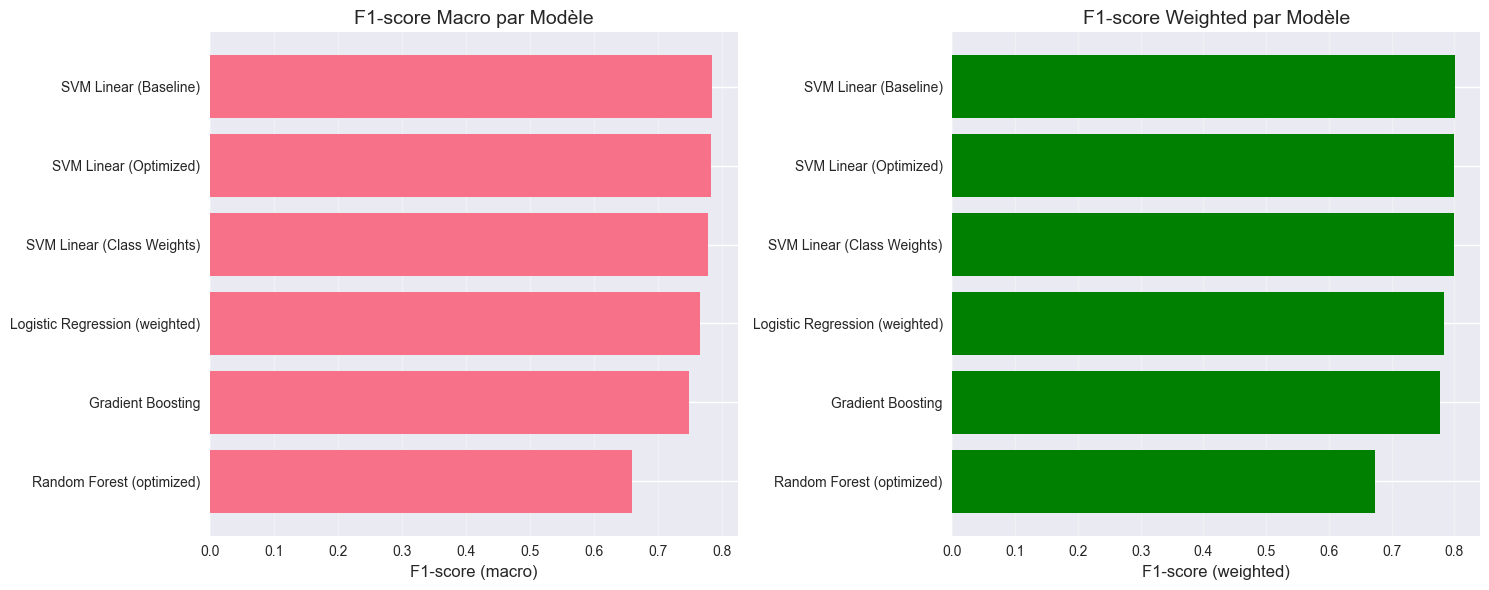

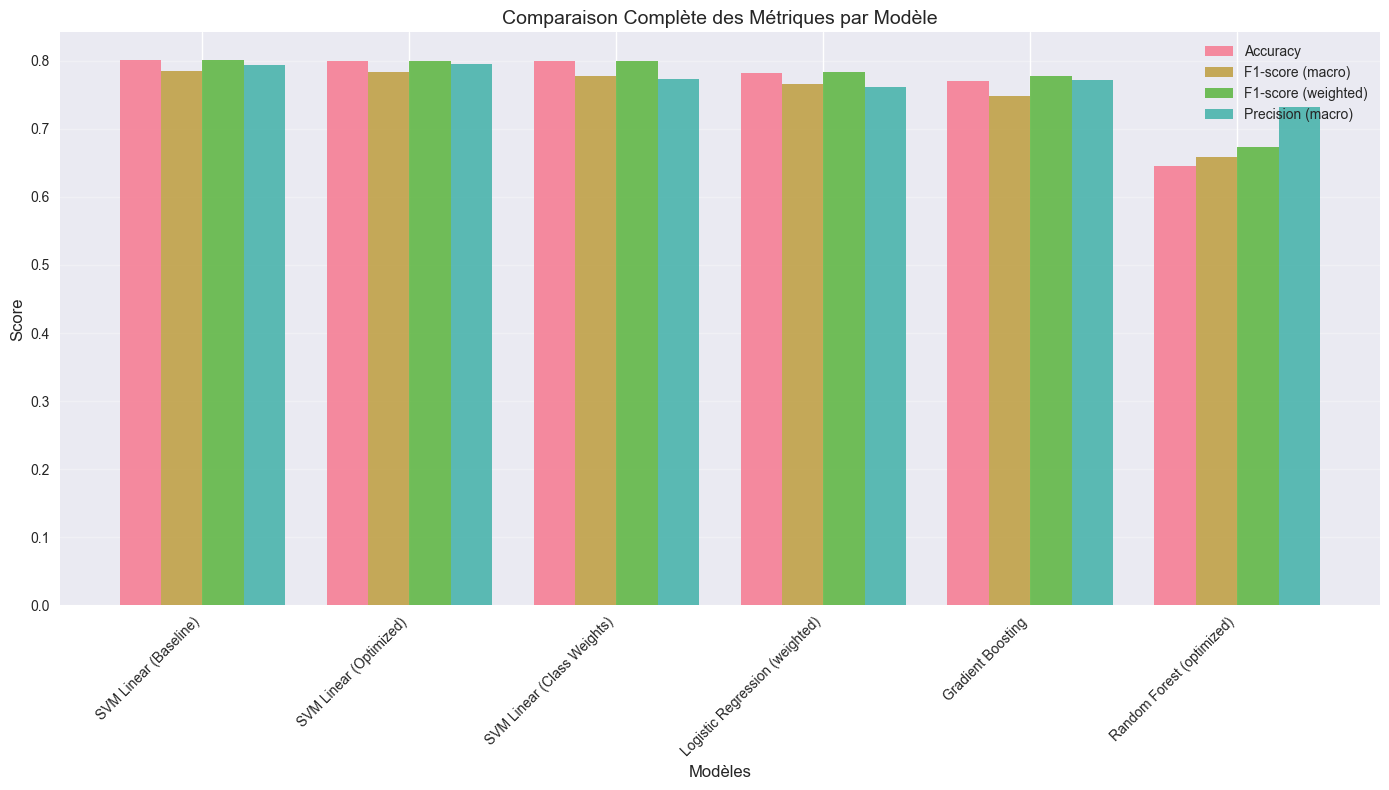

In [9]:
# Visualisation de la comparaison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# F1-score macro
axes[0].barh(results_comparison['Model'], results_comparison['F1_macro'])
axes[0].set_xlabel('F1-score (macro)', fontsize=12)
axes[0].set_title('F1-score Macro par Modèle', fontsize=14)
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# F1-score weighted
axes[1].barh(results_comparison['Model'], results_comparison['F1_weighted'], color='green')
axes[1].set_xlabel('F1-score (weighted)', fontsize=12)
axes[1].set_title('F1-score Weighted par Modèle', fontsize=14)
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Graphique comparatif complet
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(results_comparison))
width = 0.2

ax.bar(x - width*1.5, results_comparison['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x - width*0.5, results_comparison['F1_macro'], width, label='F1-score (macro)', alpha=0.8)
ax.bar(x + width*0.5, results_comparison['F1_weighted'], width, label='F1-score (weighted)', alpha=0.8)
ax.bar(x + width*1.5, results_comparison['Precision_macro'], width, label='Precision (macro)', alpha=0.8)

ax.set_xlabel('Modèles', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison Complète des Métriques par Modèle', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(results_comparison['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



## 7. Sélection du Meilleur Modèle

Identification et analyse du meilleur modèle final.


In [10]:
# Identification du meilleur modèle
best_model_name = results_comparison.iloc[0]['Model']
best_f1_macro = results_comparison.iloc[0]['F1_macro']
best_accuracy = results_comparison.iloc[0]['Accuracy']

print("="*80)
print("MEILLEUR MODÈLE IDENTIFIÉ")
print("="*80)
print(f"🏆 Modèle : {best_model_name}")
print(f"   F1-score (macro) : {best_f1_macro:.4f}")
print(f"   F1-score (weighted) : {results_comparison.iloc[0]['F1_weighted']:.4f}")
print(f"   Accuracy : {best_accuracy:.4f}")
print(f"\n📈 Amélioration vs Baseline :")
baseline_f1 = metrics_baseline['f1_macro']
improvement = (best_f1_macro - baseline_f1) / baseline_f1 * 100
print(f"   Baseline F1-macro : {baseline_f1:.4f}")
print(f"   Meilleur F1-macro : {best_f1_macro:.4f}")
print(f"   Amélioration : {improvement:+.2f}%")

# Récupération du meilleur modèle
if best_model_name == 'SVM Linear (Baseline)':
    best_model = baseline_model
    y_pred_best = y_pred_baseline
elif best_model_name == 'SVM Linear (Optimized)':
    best_model = svm_optimized['best_model']
    y_pred_best = y_pred_svm_opt
elif best_model_name == 'SVM Linear (Class Weights)':
    best_model = svm_weighted
    y_pred_best = y_pred_svm_weighted
else:
    # Modèle avancé
    best_model = advanced_models.trained_models[best_model_name]
    y_pred_best = advanced_models.predict(best_model_name, X_val_split)

# Rapport de classification détaillé
print(f"\n{'='*80}")
print(f"RAPPORT DE CLASSIFICATION DÉTAILLÉ - {best_model_name}")
print(f"{'='*80}")
class_names = [f"Classe {cls}" for cls in sorted(label_encoder.classes_)]
print_classification_report(y_val_split, y_pred_best, target_names=class_names)



MEILLEUR MODÈLE IDENTIFIÉ
🏆 Modèle : SVM Linear (Baseline)
   F1-score (macro) : 0.7843
   F1-score (weighted) : 0.8008
   Accuracy : 0.8016

📈 Amélioration vs Baseline :
   Baseline F1-macro : 0.7843
   Meilleur F1-macro : 0.7843
   Amélioration : +0.00%

RAPPORT DE CLASSIFICATION DÉTAILLÉ - SVM Linear (Baseline)
RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

   Classe 10       0.43      0.52      0.47       623
   Classe 40       0.73      0.61      0.66       502
   Classe 50       0.78      0.79      0.78       336
   Classe 60       0.95      0.83      0.89       166
 Classe 1140       0.72      0.77      0.74       534
 Classe 1160       0.87      0.91      0.89       791
 Classe 1180       0.66      0.46      0.55       153
 Classe 1280       0.73      0.67      0.70       974
 Classe 1281       0.64      0.49      0.55       414
 Classe 1300       0.88      0.93      0.90      1009
 Classe 1301       0.94      0.94      0.94       161
 Classe 1

### 7.1 Matrice de Confusion du Meilleur Modèle


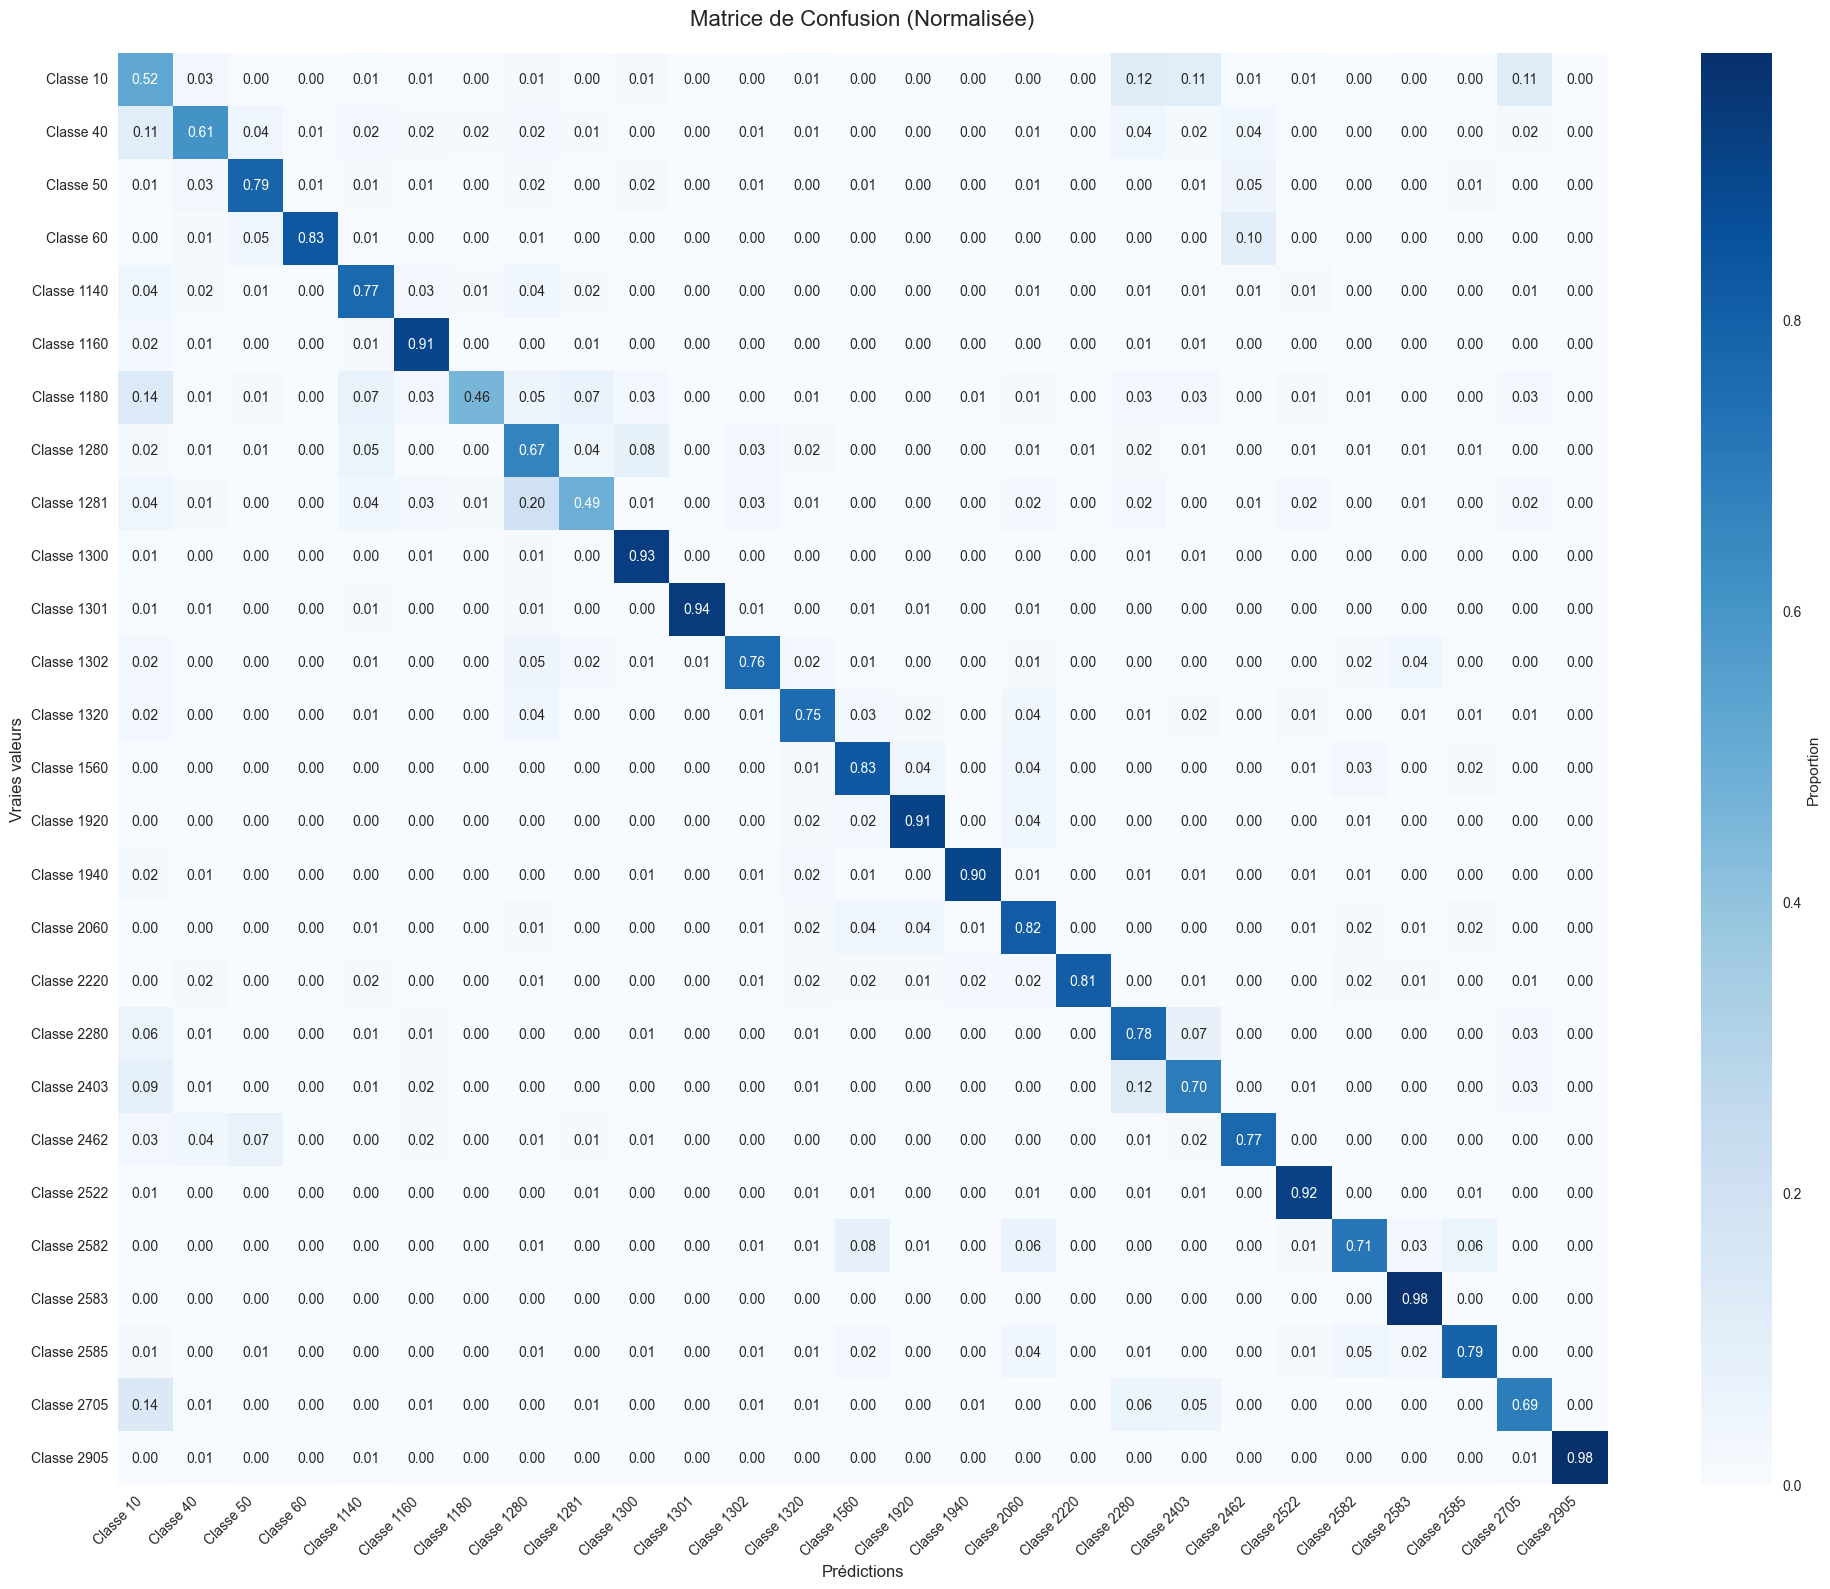

In [11]:
# Matrice de confusion
plot_confusion_matrix(
    y_val_split,
    y_pred_best,
    class_names=class_names,
    figsize=(20, 16),
    normalize=True
)



## 8. Sauvegarde du Meilleur Modèle

Sauvegarde du modèle final pour utilisation future.


In [12]:
# Sauvegarde du meilleur modèle
print("💾 Sauvegarde du meilleur modèle...")

model_filename = best_model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
model_path = MODELS_DIR / f'{model_filename}_final.pkl'

if best_model_name in advanced_models.trained_models:
    advanced_models.save_model(best_model_name, model_path)
else:
    with open(model_path, 'wb') as f:
        pickle.dump(best_model, f)

print(f"✅ Modèle sauvegardé : {model_path}")

# Sauvegarde des résultats de comparaison
results_path = MODELS_DIR / 'model_comparison_results.csv'
results_comparison.to_csv(results_path, index=False)
print(f"✅ Résultats de comparaison sauvegardés : {results_path}")



💾 Sauvegarde du meilleur modèle...
✅ Modèle sauvegardé : ..\models\svm_linear_baseline_final.pkl
✅ Résultats de comparaison sauvegardés : ..\models\model_comparison_results.csv


## 9. Synthèse et Conclusions

### Résumé des Résultats

- ✅ Modèles baseline analysés et optimisés
- ✅ Techniques de rééquilibrage testées (class weights)
- ✅ Modèles avancés testés (XGBoost, LightGBM, CatBoost, etc.)
- ✅ Meilleur modèle identifié : **[sera rempli après exécution]**
- ✅ Amélioration vs baseline : **[sera rempli après exécution]**

### Prochaines Étapes (Step 3)

1. **Modélisation avancée** : Techniques de bagging/boosting et Deep Learning
2. **Interprétabilité** : Utiliser les outils d'interprétabilité pour comprendre les résultats
3. **Conclusions scientifiques et métiers** : Analyser le succès ou l'échec de la modélisation

### Fichiers Générés

- `models/[model]_final.pkl` : Meilleur modèle final
- `models/model_comparison_results.csv` : Résultats de comparaison de tous les modèles

